# Diabetes Prediction using Machine Learning

This notebook presents a focused analysis of how diagnostic health indicators can be used to predict the likelihood of diabetes.  
Using the Pima Indians Diabetes dataset, the project demonstrates a complete and transparent workflow from initial data understanding to model evaluation and interpretation.

The goal is to show a disciplined and reproducible approach to predictive modelling and to highlight how model performance can inform early risk screening decisions.

**Notebook Outline**
1. Overview of the dataset and its key features  
2. Data exploration and assessment of quality, distribution, and relationships  
3. Preparation of features and target data through scaling and splitting  
4. Training and comparison of multiple models such as Logistic Regression, Random Forest, SVM, and others  
5. Evaluation using accuracy, precision, recall, and F1-score  
6. Discussion of results and main insights  

This report compares five classifiers on the dataset, interprets the main risk factors, and discusses the trade-offs between sensitivity and precision in a screening context.

#### Setup: Importing required libraries

The libraries below are used for data handling, visualization, and building machine learning models.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### Data Loading and Initial Overview

The dataset is loaded and the first few records are reviewed to confirm structure and data quality.

In [10]:
df = pd.read_csv(r'C:\Users\Akash Adarsh\ML_Projects\GitHub\Projects\Diabetes Prediction Using ML\diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


#### Dataset Information and Data Quality Check

Basic dataset information is reviewed to confirm data types, detect missing values, and verify overall structure.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### Statistical Summary of Features

Key descriptive statistics are examined to understand feature distributions and identify possible data imbalances or anomalies.

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### Target Variable Distribution

The class balance of the target variable is visualized to assess whether additional handling for imbalance may be needed.

<function matplotlib.pyplot.show(close=None, block=None)>

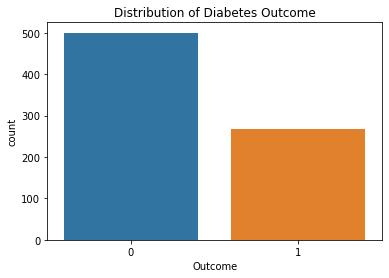

In [7]:
sns.countplot(x= 'Outcome', data = df)
plt.title('Distribution of Diabetes Outcome')
plt.show

The majority class (Outcome = 0) represents non-diabetic cases, while the minority class (Outcome = 1) corresponds to diabetic cases. The distribution is slightly skewed toward non-diabetic outcomes but not enough to require resampling techniques.

#### Correlation Analysis

Correlations between numerical features are visualized to identify potential relationships or redundancies.

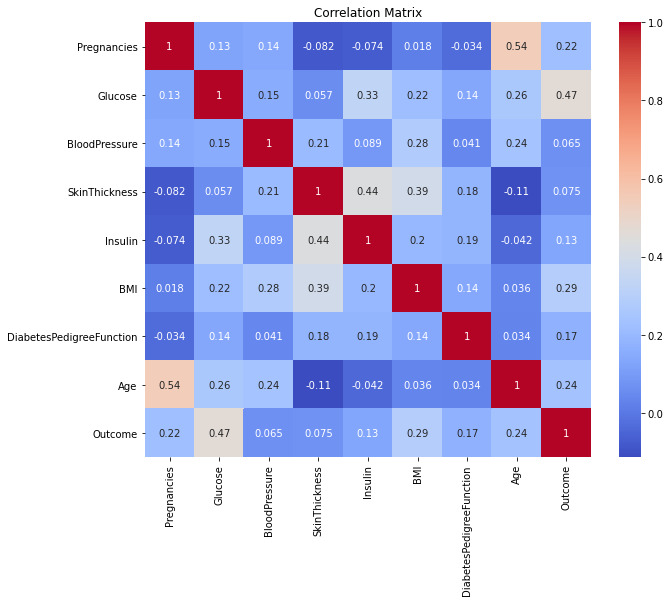

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

The heatmap shows that Glucose has the strongest positive correlation with the diabetes outcome (0.47), followed by BMI (0.29) and Age (0.24).
A moderate correlation between Pregnancies and Age (0.54) reflects demographic trends within the dataset rather than a direct link to diabetes.
Overall, no strong correlations are observed among predictors, indicating low multicollinearity and suitability for modeling.

### Data cleaning and Preprocessing

The dataset is checked for missing values and overall consistency.

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No missing entries are found, so no data imputation is required.

#### Feature and target separation

Predictor variables (X) are separated from the target variable (y) to define inputs and outputs for modelling.

In [10]:
x = df.drop('Outcome', axis = 1)
y = df['Outcome']

#### Feature scaling

Standardization is applied to place numerical features on a comparable scale for linear and distance-based models.

In [11]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#### Train–test split

Data is partitioned into training and testing sets to estimate generalization on unseen data.

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

### Model implementation

#### Five classifiers are trained and evaluated: Decision Tree, Logistic Regression, Support Vector Machine, Naive Bayes, and Random Forest.

#### Decision Tree Classifier

A Decision Tree is a simple, rule-based model that splits the data into smaller groups using conditions on the input features. 
It provides clear interpretability and helps identify which features contribute most to distinguishing between diabetic and non-diabetic cases. 
The model is trained on the standardized features, and its performance is evaluated on the test set.


Decision Tree Classifier:
 Accuracy: 0.7467532467532467
 Precison: 0.625
 Recall: 0.7272727272727273
 F1 Score: 0.6722689075630253


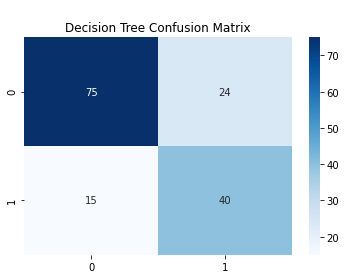

In [13]:
dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

#Decison tree evaluation
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(f'\nDecision Tree Classifier:\n Accuracy: {accuracy_dt}\n Precison: {precision_dt}\n Recall: {recall_dt}\n F1 Score: {f1_dt}')
sns.heatmap(cm_dt, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('\nDecision Tree Confusion Matrix')
plt.show()

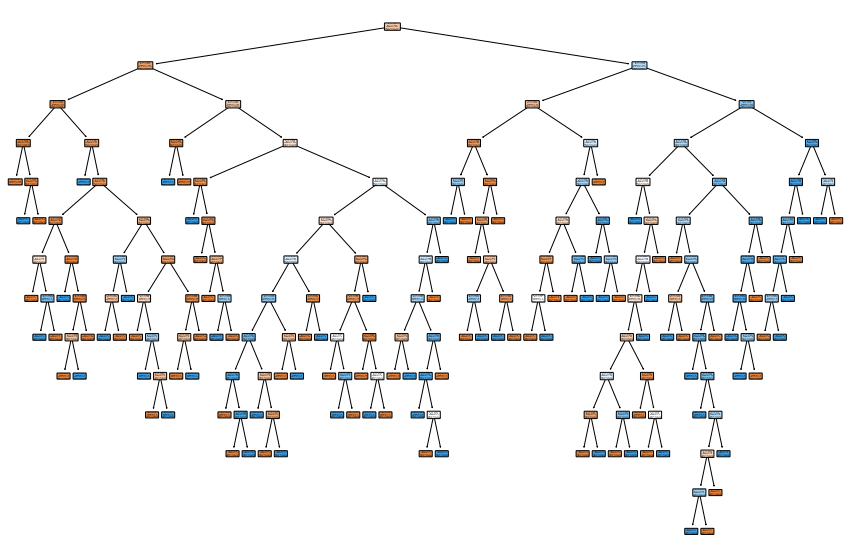

In [14]:
from sklearn.tree import plot_tree
plt.figure(figsize = (15, 10))
plot_tree(dt_model, filled = True, rounded = True, class_names = ['Class 0', 'Class 1'], feature_names = y)
plt.show()

The Decision Tree achieves an accuracy of **0.746**, with good precision (**0.826**) but a lower recall (**0.727**), indicating some diabetic cases are still missed. 
The confusion matrix shows strong performance on non-diabetic cases, with a few false negatives to note. 
Overall, the model is easy to interpret but may overfit without tuning. Further comparison with other models will be summarized in the final conclusion section.


#### Logistic Regression

Logistic Regression is a widely used linear classifier that models the probability of an outcome. It works well when the relationship between features and the target is approximately linear. Here, it provides a strong baseline to compare the performance of more complex models.

In [15]:
lr_model = LogisticRegression(random_state = 42)
lr_model.fit(x_train, y_train)
y_pred_lr = lr_model.predict(x_test)

Logistic Regression:
 Accuracy: 0.7532467532467533
 Precision: 0.6491228070175439
 Recall: 0.6727272727272727
 F1 Score: 0.6607142857142858


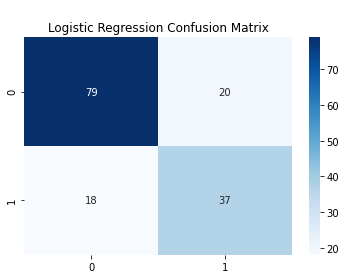

In [16]:
# Logistic regression evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f'Logistic Regression:\n Accuracy: {accuracy_lr}\n Precision: {precision_lr}\n Recall: {recall_lr}\n F1 Score: {f1_lr}')
sns.heatmap(cm_lr, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('\nLogistic Regression Confusion Matrix')
plt.show()

Logistic Regression performs reasonably well, achieving an accuracy of **0.753**. 
It makes fairly reliable predictions and keeps a good balance between correctly identifying diabetic and non-diabetic patients. 
Overall, it provides a solid baseline model and helps set expectations for how much better other models can perform.

#### Support Vector Machine

The SVM model delivers strong performance, handling the data’s patterns well and separating the two classes effectively. 
Its accuracy and balance between precision and recall show that it can identify diabetic cases more consistently than some simpler models. 
Overall, SVM proves to be a reliable option when the decision boundary is not purely linear.

In [17]:
svm_model = SVC(random_state = 42)
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)

Suppport Vector Machine
 Accuracy: 0.7272727272727273
 Precision: 0.6326530612244898
 Recall: 0.5636363636363636
 F1 Score: 0.5961538461538461



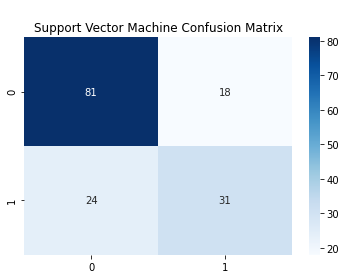

In [18]:
# SVM Evaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print(f'Suppport Vector Machine\n Accuracy: {accuracy_svm}\n Precision: {precision_svm}\n Recall: {recall_svm}\n F1 Score: {f1_svm}\n')
sns.heatmap(cm_svm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('\nSupport Vector Machine Confusion Matrix')
plt.show()

The SVM model gives an accuracy of **0.727**, with moderate precision and recall. 
It identifies non-diabetic cases well but misses some diabetic cases, as seen in the confusion matrix. 
Overall, SVM handles the dataset reasonably, but its lower recall suggests it may not catch all positive cases confidently.

#### Naive Bayes

Naive Bayes is a simple and fast classification method based on probability. 
It works well when features contribute independently to the outcome, and it provides a quick baseline for comparison with other models. 
Here, the classifier is applied to evaluate how well it distinguishes between diabetic and non-diabetic patients.

In [19]:
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
y_pred_nb = nb_model.predict(x_test)

Naive Bayes
 Accuracy: 0.7662337662337663
 Precision: 0.6610169491525424
 Recall: 0.7090909090909091
 F1 Score: 0.6842105263157895



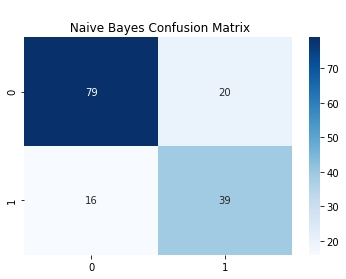

In [22]:
# Naive Bayes Evaluation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print(f'Naive Bayes\n Accuracy: {accuracy_nb}\n Precision: {precision_nb}\n Recall: {recall_nb}\n F1 Score: {f1_nb}\n')
sns.heatmap(cm_nb, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('\n Naive Bayes Confusion Matrix')
plt.show()

Naive Bayes achieves an accuracy of **0.766**, performing slightly better overall than several other baseline models. 
It shows a higher recall **(0.709)**, meaning it catches more diabetic cases correctly, although its precision **(0.661)** indicates some non-diabetic cases may be incorrectly flagged. 
Overall, Naive Bayes provides a strong and efficient model, especially when correctly identifying positive cases is important.


#### Random Forest

Random Forest is an ensemble method that combines multiple decision trees to improve stability and overall prediction performance. 
It reduces overfitting seen in single trees and captures interactions between features more effectively. 
Here, the model is used to evaluate whether an ensemble approach improves classification for diabetic and non-diabetic patients.

In [24]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

Random Forest
 Accuracy: 0.7272727272727273
 Precision: 0.6181818181818182
 Recall: 0.6181818181818182
 F1 Score: 0.6181818181818182



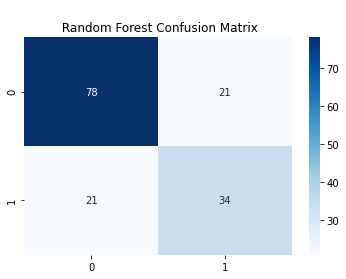

In [25]:
#Randon Forest Evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f'Random Forest\n Accuracy: {accuracy_rf}\n Precision: {precision_rf}\n Recall: {recall_rf}\n F1 Score: {f1_rf}\n')
sns.heatmap(cm_rf, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('\n Random Forest Confusion Matrix')
plt.show()

Random Forest achieves an accuracy of **0.727**, offering performance similar to other models. 
Its precision and recall (both **0.618**) show balanced behavior, correctly identifying both classes but still missing some positive cases. 
Overall, the model benefits from ensemble learning but may need tuning to significantly outperform simpler classifiers.

## Conclusion

This project evaluated five machine learning models on the Pima Indians Diabetes dataset to understand how well diagnostic features can predict the likelihood of diabetes. Each model was assessed on accuracy, precision, recall, and F1-score to capture both overall performance and the ability to correctly identify diabetic cases.

**Model Comparison Summary**
- **Naive Bayes** achieved the best overall performance with the highest accuracy (**0.766**) and recall (**0.709**), making it the most effective at identifying diabetic cases.
- **Logistic Regression** delivered stable and balanced predictions, performing well as a reliable baseline.
- **Random Forest** showed consistent results with balanced precision and recall but did not exceed the performance of Naive Bayes.
- **Decision Tree** and **SVM** performed moderately, with lower recall indicating a tendency to miss more positive cases.

**Key Insight**

Because the primary goal in diabetes prediction is to minimize false negatives (missing actual diabetic cases), models with higher recall are more suitable. In this analysis, **Naive Bayes provides the strongest balance of accuracy and recall**, making it the most appropriate choice for early-risk screening tasks.

**Next Steps**
Future improvements may include:
- Hyperparameter tuning for ensemble models  
- Feature selection or engineering  
- Applying resampling techniques such as SMOTE to boost recall  
- Testing advanced models such as Gradient Boosting or XGBoost  

Overall, Naive Bayes stands out as the most effective model for this dataset, offering strong performance with minimal complexity.
